In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Names and PRN for all group members:
- Name: ______________________
- PRN:  ______________________
- Date: ______________________

# Image Processing with Neural Network
## A07: Group Assignment


##  Convolutional Neural Network (CNN)

- Flowers Dataset


In [42]:
###-----------------
### Import Libraries
###-----------------
import os
import pandas as pd
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import accuracy_score,classification_report
from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix,fn_plot_label

    
%matplotlib inline

In [3]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('../../input') # location where input data is stored
outDir = Path('../output') # location to store outputs
subDir = 'flower_photos' # location of the images
modelDir = Path('../models') # location to save model files
valDir = 'valid_flowers' # location related to this dataset
altName = 'base_flowers' # Model file name for this alternative

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
tf.random.set_seed(RANDOM_STATE)


EPOCHS = 100   # number of cycles to run
ALPHA = 0.001
BATCH_SIZE = 16
TEST_SIZE = 0.2
IMG_HEIGHT = 190
IMG_WIDTH = 190

# Transformations
# flipping
FLIP_MODE = "horizontal_and_vertical"
# Rotation
ROTATION_FACTOR = (-0.1, 0.1) 
# filling mode
FILL_MODE = 'nearest'


## Early Stopping
ES_PATIENCE = 20 # if performance does not improve stop
# Learning rates
LR_PATIENCE = 10 # if performace is not improving reduce alpha
LR_FACTOR = 0.5 # rate of reduction of alpha


# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (15,8),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

## Basic Hygiene

In [4]:
###------------------
### Memory Management
###------------------

physical_devices = tf.config.list_physical_devices('GPU') 

if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print (physical_devices)
else:
    print ('Error: No GPU device found')

Error: No GPU device found


## Helper Functions
**Note** all helper functions have been moved to util.helper

## Load Dataset

Images are under flower_photos

     |- daisy
     |- dandelion
     |- roses
     |- sunflowers
     |- tulips

In [5]:
'''
    For reading from web link
'''

# import pathlib
# dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
# data_dir = tf.keras.utils.get_file(origin=dataset_url,
#                                   fname='flower_photos',
#                                   untar=True)
# data_dir = pathlib.Path(data_dir) / 'flower_photos'
# '''
#     For reading from local directory
# '''
data_dir = os.path.join('../datasets/dnn_input/flower_photos/')

In [6]:
data_dir

'../datasets/dnn_input/flower_photos/'

In [7]:
# list content of data_dir
os.listdir(data_dir)

['LICENSE.txt', 'daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

In [8]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=TEST_SIZE,
    subset='training',
    seed= RANDOM_STATE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=TEST_SIZE,
    subset='validation',
    seed= RANDOM_STATE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


### Is it picking the class names?

In [9]:
class_names = train_ds.class_names
num_classes = len(class_names)
print('total ', num_classes, class_names)

total  5 ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Verify the data

To verify that the dataset looks correct, let's plot the first batch from the training set and display the class name below each image.


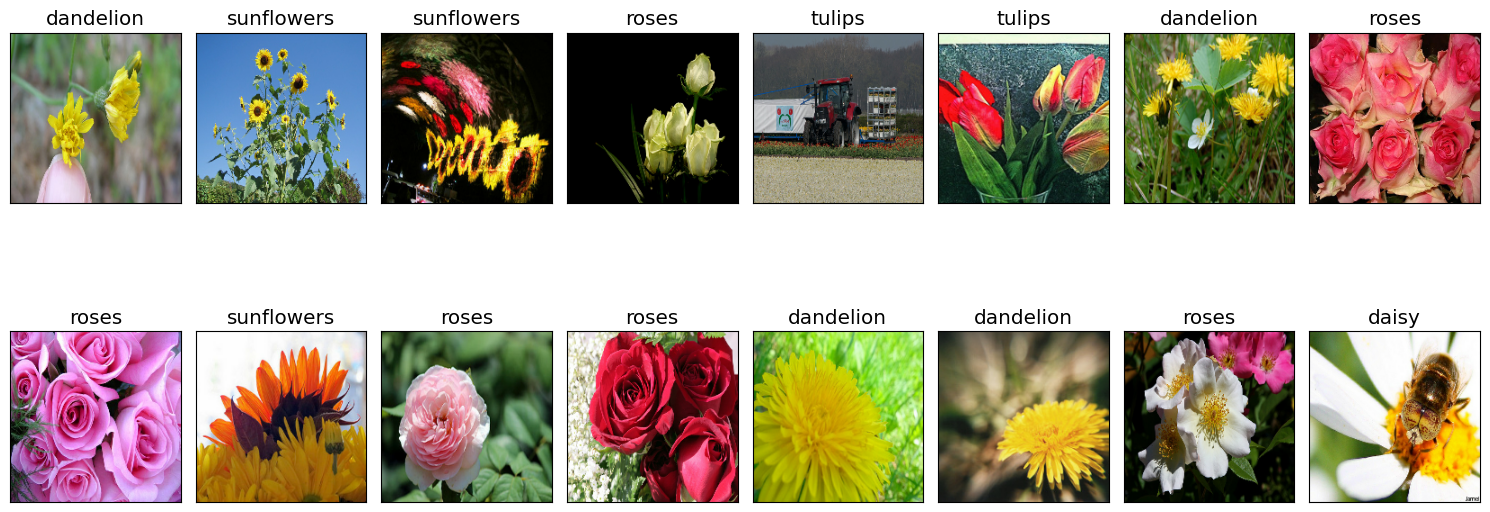

In [10]:
# set figure size
fig = plt.figure()  # figure size in inches with default params

# Adjust the subplot layout parameters.
fig.subplots_adjust(left=0., # as a fraction of the figure width
                    right=1., # use full width, as a fraction of the figure width
                    bottom=0., # as a fraction of the figure height
                    top=1., # as a fraction of the figure height
                    hspace=0.05, # as a fraction of the average Axes height
                    wspace=0.05) # width of the padding between subplots

# take one batch of the dataset
for images, labels in train_ds.take(1):
    
    # iterate through the batch
    for i in range(BATCH_SIZE):
        
        # add a subplot
        ax = fig.add_subplot( BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[]) # add a subplot to the figure
        
        # image_size may have converted these images to float
        ax.imshow(images[i].numpy().astype("uint8")) 
        
        # display class in the title
        ax.set_title(class_names[labels[i]])
        
# fit the subplot(s) in to the figure area
plt.tight_layout()
    
# display all open images    
plt.show()

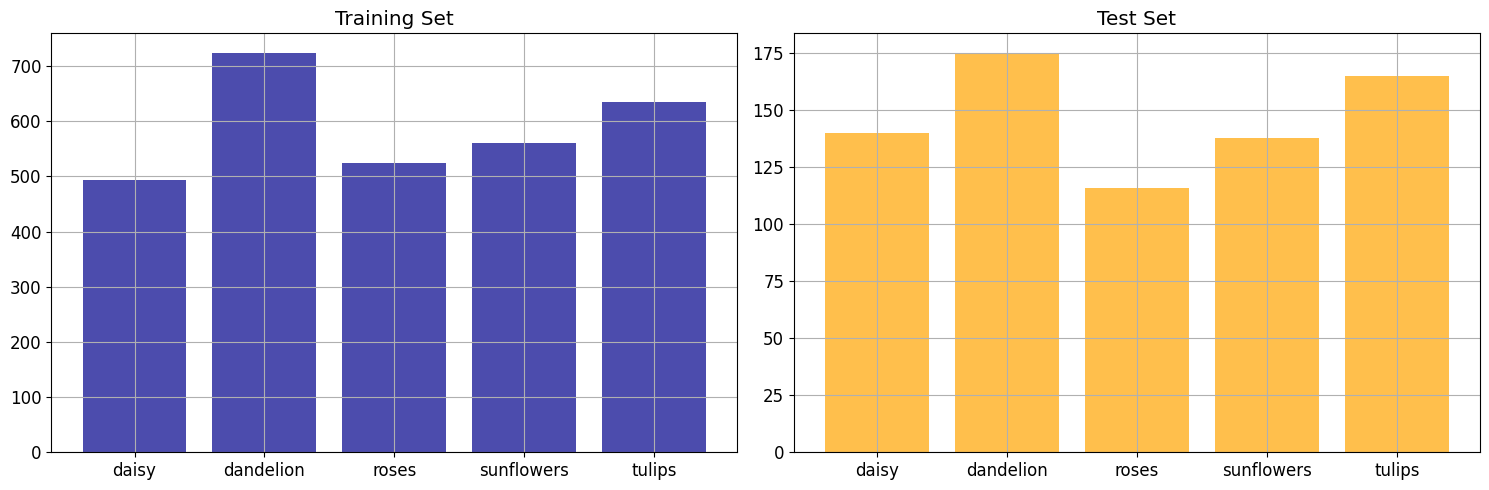

In [11]:
# how many examples in each of the class
fn_plot_label(train_ds, test_ds)

In [12]:
images[0].shape

TensorShape([190, 190, 3])

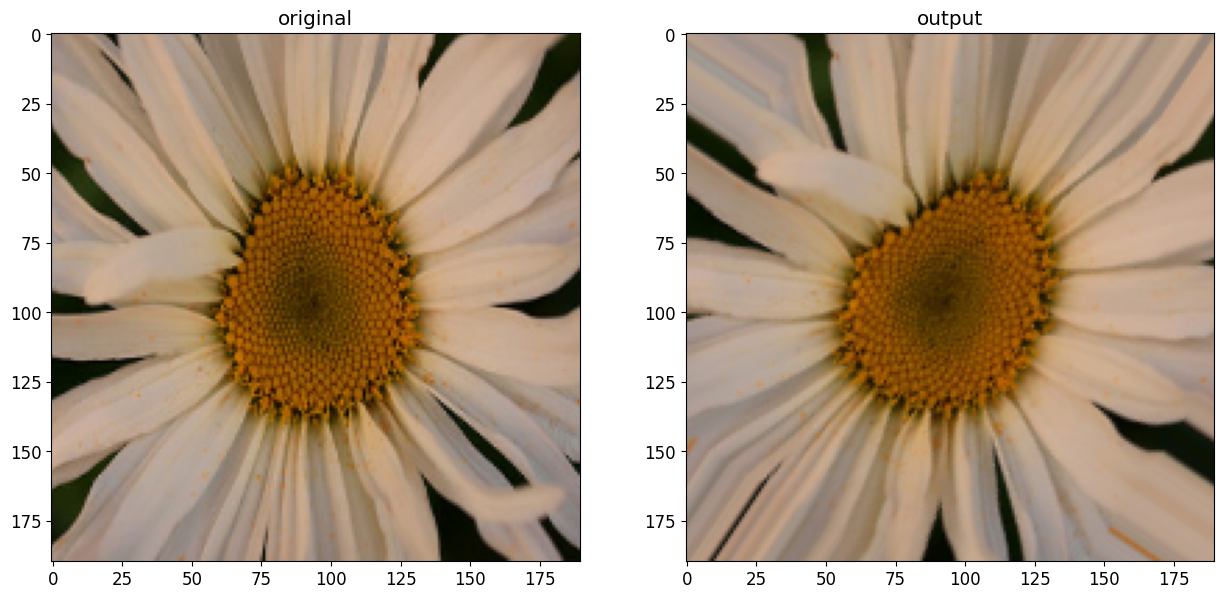

In [30]:
# layer = tf.keras.layers.RandomZoom(height_factor = (-0.2,0.2),
#                              width_factor = (-0.2,0.2))

layer = tf.keras.layers.RandomRotation((-0.5,0.5),fill_mode='nearest')

plt.figure()
img_num = 0
for images,labels in train_ds.take(1):
    out_images = layer(images)
plt.subplot(1,2,1)
plt.title('original')
plt.imshow(images[img_num].numpy().astype('uint16'))

plt.subplot(1,2,2)
plt.title('output')
plt.imshow(out_images[img_num].numpy().astype('uint16'))

<h1>BUILD MODEL</h1>

In [13]:
input_shape = [IMG_HEIGHT,IMG_WIDTH,3]

In [15]:
def build_model(input_shape, num_classes):

    
    
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape = input_shape))
    model.add(tf.keras.layers.Rescaling(1./255))
    

    #set 1
    model.add(tf.keras.layers.Conv2D(32, (3,3))) #188 x 188 x 32
    model.add(tf.keras.layers.ReLU()) 
    model.add(tf.keras.layers.MaxPool2D()) # 94 x 94 x32

    #set 2
    model.add(tf.keras.layers.Conv2D(64, (3,3))) #92 x 92 x 64
    model.add(tf.keras.layers.ReLU()) 
    model.add(tf.keras.layers.MaxPool2D()) # 46 x 46 x64

    #set 3
    model.add(tf.keras.layers.Conv2D(128, (3,3))) #44 x 44 x 128
    model.add(tf.keras.layers.ReLU()) 
    model.add(tf.keras.layers.MaxPool2D()) # 22 x 22 x128

    #set 4
    model.add(tf.keras.layers.Conv2D(256, (3,3))) #20 x 20 x 256
    model.add(tf.keras.layers.ReLU()) 
    model.add(tf.keras.layers.MaxPool2D()) # 10 x 10 x256

    #set 5
    model.add(tf.keras.layers.Conv2D(512, (3,3))) # 8 x 8 x 512
    model.add(tf.keras.layers.ReLU()) 
    model.add(tf.keras.layers.MaxPool2D()) # 4 x 4 x512

    #set 6
    model.add(tf.keras.layers.Conv2D(1024, (3,3))) #2 x 2 x 1024
    model.add(tf.keras.layers.ReLU()) 
    model.add(tf.keras.layers.Flatten()) # 4096

    # Head
    model.add(tf.keras.layers.Dense(1024)) # 1024
    model.add(tf.keras.layers.ReLU()) 


    #Output
    model.add(tf.keras.layers.Dense(num_classes)) 


    

    
    return model
model = build_model(input_shape,num_classes)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 190, 190, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 188, 188, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_7 (ReLU)                       │ (None, 188, 188, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 94, 94, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 92, 92, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_8 (ReLU)                       │ (None, 92, 92, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 46, 46, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 44, 44, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_9 (ReLU)                       │ (None, 44, 44, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 22, 22, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 20, 20, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_10 (ReLU)                      │ (None, 20, 20, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 8, 8, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_11 (ReLU)                      │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 2, 2, 1024)          │       4,719,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_12 (ReLU)                      │ (None, 2, 2, 1024)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1024)                │       4,195,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_13 (ReLU)                      │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 10,488,645 (40.01 MB)

 Trainable params: 10,488,645 (40.01 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
#call backs
PATIENCE = 20
LR_FACTOR =0.1 
LR_PATIENCE = 5
MIN_LR = 1e-6

es_callback = tf.keras.callbacks.EarlyStopping(monitor= 'val_loss',
                                              patience=PATIENCE,
                                              verbose = 1,
                                              restore_best_weights=True,
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
   monitor='val_loss',
    factor= LR_FACTOR,
    patience = LR_PATIENCE,
    verbose = 1,
    mode = 'auto',
    min_lr=MIN_LR
)



In [35]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate = ALPHA)
model.compile(optimizer = optimizer,
             loss = loss_fn,
            
             metrics = ['accuracy'])

In [36]:
history = model.fit(train_ds,
         validation_data=test_ds,
         epochs= EPOCHS,
         callbacks=[es_callback,lr_callback])

Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 58s 303ms/step - accuracy: 0.3464 - loss: 1.4206 - val_accuracy: 0.3965 - val_loss: 1.3750 - learning_rate: 0.0010
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 56s 303ms/step - accuracy: 0.4077 - loss: 1.2981 - val_accuracy: 0.4005 - val_loss: 1.3321 - learning_rate: 0.0010
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 56s 302ms/step - accuracy: 0.4394 - loss: 1.2741 - val_accuracy: 0.4251 - val_loss: 1.3384 - learning_rate: 0.0010
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 56s 306ms/step - accuracy: 0.4748 - loss: 1.2443 - val_accuracy: 0.5041 - val_loss: 1.2556 - learning_rate: 0.0010
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 56s 304ms/step - accuracy: 0.5347 - loss: 1.1452 - val_accuracy: 0.4986 - val_loss: 1.1543 - learning_rate: 0.0010
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 56s 305ms/step - accuracy: 0.5337 - loss: 1.0899 - val_accuracy: 0.5327 - val_loss: 1.1516 - learning_rate: 0.0010
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 58s 313ms/step - accura

### Reload best Weights for evaluation

### Evaluate the model

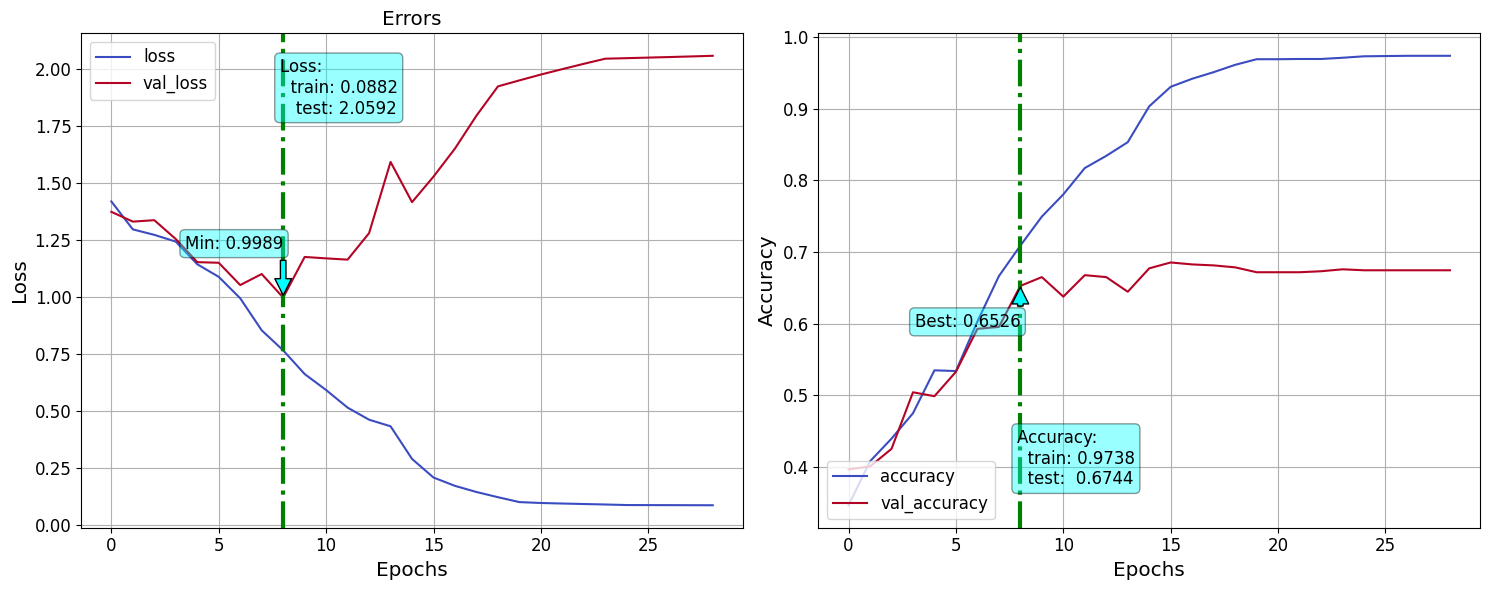

In [39]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

In [40]:
y_train = tf.concat([y for x, y in train_ds], axis=0).numpy()
print(y_train.shape)

(2936,)


In [43]:
yhat = model.predict(train_ds)
y_pred = yhat.argmax(axis=1)
print(f'Accuracy: {accuracy_score(y_train, y_pred):.5f}')
print(classification_report(y_train, y_pred))

184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step
Accuracy: 0.21628
              precision    recall  f1-score   support

           0       0.18      0.21      0.20       493
           1       0.27      0.31      0.29       723
           2       0.19      0.14      0.16       525
           3       0.20      0.23      0.21       561
           4       0.20      0.16      0.18       634

    accuracy                           0.22      2936
   macro avg       0.21      0.21      0.21      2936
weighted avg       0.21      0.22      0.21      2936



## Validate on the validation set

In [ ]:
data_dir = os.path.join(inpDir, valDir)
valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=None,
    #subset='validation',
    seed= RANDOM_STATE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

valid_ds = valid_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
# set figure size
fig = plt.figure()  # figure size in inches with default params

# Adjust the subplot layout parameters.
fig.subplots_adjust(left=0., # as a fraction of the figure width
                    right=1., # use full width, as a fraction of the figure width
                    bottom=0., # as a fraction of the figure height
                    top=1., # as a fraction of the figure height
                    hspace=0.05, # as a fraction of the average Axes height
                    wspace=0.05) # width of the padding between subplots
i = 0
# take one batch of the dataset
for images, labels in valid_ds.take(1):
    
    # iterate through the batch
    for i in range(BATCH_SIZE):
        
        # add a subplot
        ax = fig.add_subplot( BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[]) # add a subplot to the figure
        
        # image_size may have converted these images to float
        ax.imshow(images[i].numpy().astype("uint8")) 
        
        # display class in the title
        ax.set_title(class_names[labels[i]])
        
# fit the subplot(s) in to the figure area
plt.tight_layout()
    
# display all open images    
plt.show()

In [ ]:
loss, acc = new_model.evaluate(valid_ds)

print('Accuracy score on Validation Data : {:.3f}%'.format( acc*100))

In [ ]:
for images, labels in valid_ds.take(2 ):
    
    # Predict again to keep y_pred in synch with the images
    yhat = new_model.predict(images, verbose = 0)
    
    y_pred = yhat.argmax(axis = 1)
    fontsize = 12
    fig = plt.figure()  # figure with default size in inches
    
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05) # adjust subplots

    for i in range ( BATCH_SIZE ):
        
        if labels.numpy()[i]!= y_pred[i]:
            fc = 'purple'
            ec="red"
            text_color = 'yellow'
        else:
            fc = 'cyan'
            ec = 'blue'
            text_color = 'blue'

        props = dict(boxstyle='round', facecolor=fc, alpha=0.7, ec = ec)
        
        ax = fig.add_subplot(BATCH_SIZE // 8 , 8, (i+1), xticks=[], yticks=[]) # add a subplot to the figure
        
        ax.imshow ( images[i].numpy().astype( "uint8" ) )
        
        ax.text(0.1, 0.95, class_names[y_pred[i]], transform=ax.transAxes, 
                fontsize=fontsize, color = text_color,
            verticalalignment='top', bbox=props)   # add number (class) of the image

        
        ax.set_title(class_names[labels.numpy()[i]])
        #ax.set_title('{} \n {}'.format( class_names[labels.numpy()[i]], ))
        
        ax.axis("off")
        
    plt.tight_layout()
    
    plt.show()